# Cleaning

In [12]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy import text

flights_data = pd.read_csv('flight_data_2024_sampled.csv')
engine = create_engine('sqlite:///flights.db')
flights_data.to_sql('flights', engine, if_exists='replace', index=False)

head_query = "SELECT * FROM flights LIMIT 10;"
head_flights = pd.read_sql(head_query, engine)
print(head_flights)

with engine.begin() as conn:
    conn.execute(text("""
        ALTER TABLE flights
        ADD COLUMN delay_in_minutes INTEGER;
    """))
    
    conn.execute(text("""
        UPDATE flights
        SET delay_in_minutes = arr_delay + dep_delay
    """))
    
head_flights = pd.read_sql(head_query, engine)

with engine.begin() as conn:
    conn.execute(text("""
        ALTER TABLE flights
        ADD COLUMN IS_Delay BOOL;
    """))
    
    conn.execute(text("""
        UPDATE flights
        SET IS_Delay = CASE 
        WHEN COALESCE(delay_in_minutes,0) >= 10 THEN 1
        ELSE 0
        END;
    """))
    
with engine.begin() as conn:
    conn.execute(text("""
        UPDATE flights
        SET 
            carrier_delay = CASE WHEN IS_Delay = 0 THEN 0 ELSE carrier_delay END,
            weather_delay = CASE WHEN IS_Delay = 0 THEN 0 ELSE weather_delay END,
            nas_delay = CASE WHEN IS_Delay = 0 THEN 0 ELSE nas_delay END,
            security_delay = CASE WHEN IS_Delay = 0 THEN 0 ELSE security_delay END,
            late_aircraft_delay = CASE WHEN IS_Delay = 0 THEN 0 ELSE late_aircraft_delay END;
    """))

with engine.begin() as conn:
    conn.execute(text("""
        ALTER TABLE flights
        ADD COLUMN Season TEXT;
    """))
    
    conn.execute(text("""
        UPDATE flights
        SET Season = CASE WHEN month IN (12, 1, 2) THEN 'Winter'
        WHEN month IN (3, 4, 5) THEN 'Spring'
        WHEN month IN (6, 7, 8) THEN 'Summer'   
        WHEN month IN (9, 10, 11) THEN 'Fall'
        ELSE 'Unknown'
        END;
    """))

with engine.begin() as conn:
    conn.execute(text("""
        ALTER TABLE flights
        ADD COLUMN Departure_Hour INTEGER;
    """))
    
    conn.execute(text("""
        UPDATE flights
        SET Departure_Hour = CASE 
            WHEN Crs_dep_time IS NOT NULL THEN CAST(SUBSTR(printf('%04d', Crs_dep_time), 1, 2) AS INTEGER)
            ELSE NULL
        END;
    """))
    
# USE df (from SQLite) instead of flights_data
df = pd.read_sql("SELECT * FROM flights;", engine)

# 1. Keep only city part (before comma) - now works on df
df['origin_city_name'] = df['origin_city_name'].str.split(',').str[0]
df['dest_city_name'] = df['dest_city_name'].str.split(',').str[0]

# 2. Rename columns
df = df.rename(columns={
    'origin_city_name': 'origin_city',
    'dest_city_name': 'dest_city',
    'origin_state_nm': 'origin_state',
    'dest_state_nm': 'dest_state'
})

df.to_csv('flight_clean.csv', index=False)


   year  month  day_of_month  day_of_week     fl_date op_unique_carrier  \
0  2024      7            26            5  2024-07-26                UA   
1  2024      6            18            2  2024-06-18                9E   
2  2024      5            26            7  2024-05-26                DL   
3  2024     11            23            6  2024-11-23                WN   
4  2024      6            15            6  2024-06-15                WN   
5  2024      2             9            5  2024-02-09                UA   
6  2024      4             7            7  2024-04-07                OO   
7  2024      2            23            5  2024-02-23                DL   
8  2024     11             2            6  2024-11-02                UA   
9  2024      5             1            3  2024-05-01                OO   

   op_carrier_fl_num origin origin_city_name origin_state_nm  ... diverted  \
0              699.0    RNO         Reno, NV          Nevada  ...        0   
1             5196

0     551.0
1    2112.0
2    1553.0
3    1428.0
4    2103.0
5     832.0
6    1027.0
7    1553.0
8     930.0
9    1533.0
Name: dep_time, dtype: float64

# Cleaning weather

In [5]:
import pandas as pd
from sqlalchemy import create_engine

weather_df = pd.read_csv('weather_data_sampled.csv')
engine = create_engine('sqlite:///:memory:')
weather_df.to_sql('weather', engine, index=False)

query = """
SELECT 
    Location,
    Date_Time,
    Temperature_C,
    Humidity_pct,
    Precipitation_mm,
    Wind_Speed_kmh,
    strftime('%H', Date_Time) AS Hour,
    strftime('%m', Date_Time) AS Month_Number,
    CASE strftime('%m', Date_Time)
        WHEN '01' THEN 'January'
        WHEN '02' THEN 'February'
        WHEN '03' THEN 'March'
        WHEN '04' THEN 'April'
        WHEN '05' THEN 'May'
        WHEN '06' THEN 'June'
        WHEN '07' THEN 'July'
        WHEN '08' THEN 'August'
        WHEN '09' THEN 'September'
        WHEN '10' THEN 'October'
        WHEN '11' THEN 'November'
        WHEN '12' THEN 'December'
    END AS Month_Name,
    strftime('%d', Date_Time) AS Day_of_Month,
    CASE strftime('%w', Date_Time)
        WHEN '0' THEN 'Sunday'
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
    END AS Weekday
FROM weather;
"""

result = pd.read_sql(query, engine)
result.to_csv('weather_clean.csv', index=False)

# Joining the data

In [13]:
import pandas as pd

file_path = "flight_clean.csv"
weather_path = "weather_clean.csv"
output_path = "merged_flights.csv"


def drop_duplicate_columns(df):
    seen = {}
    cols_to_drop = []

    for col in df.columns:
        base = col.lower().rstrip("_xy").rstrip("_")
        if base in seen:
            cols_to_drop.append(col)
        else:
            seen[base] = col

    if cols_to_drop:
        print(f"Dropping duplicate columns: {cols_to_drop}")
        df = df.drop(columns=cols_to_drop)

    return df


def perform_merge(flights, weather):
    flights = flights.dropna(subset=['Departure_Hour'])
    
    flights["fl_datetime"] = pd.to_datetime(flights["fl_date"]) + pd.to_timedelta(flights["Departure_Hour"], unit="h")
    
    flights = flights.dropna(subset=["fl_datetime"])
    # Build proper datetime for flights: fl_date + Departure_Hour
    # e.g. 2024-01-04 + hour 9 -> 2024-01-04 09:00:00
    flights["fl_datetime"] = pd.to_datetime(flights["fl_date"]) + pd.to_timedelta(flights["Departure_Hour"], unit="h")

    weather["Date_Time"] = pd.to_datetime(weather["Date_Time"])

    # Sort for merge_asof
    flights = flights.sort_values("fl_datetime").reset_index(drop=True)
    weather = weather.sort_values("Date_Time").reset_index(drop=True)

    # Rename weather location to match flights origin_city
    weather_renamed = weather.rename(columns={"Location": "origin_city"})
    weather_cols = [c for c in weather.columns if c not in ["Location", "Date_Time"]]

    merged_parts = []

    for city, flight_group in flights.groupby("origin_city"):
        weather_group = weather_renamed[weather_renamed["origin_city"] == city].copy()

        if weather_group.empty:
            for col in weather_cols:
                flight_group[col] = None
            flight_group["Date_Time"] = pd.NaT
            merged_parts.append(flight_group)
            continue

        merged_city = pd.merge_asof(
            flight_group.sort_values("fl_datetime"),
            weather_group.sort_values("Date_Time"),
            left_on="fl_datetime",
            right_on="Date_Time",
            by="origin_city",
            direction="nearest",
            tolerance=pd.Timedelta("3H")
        )
        merged_parts.append(merged_city)

    merged = pd.concat(merged_parts, ignore_index=True)

    # Add Weather_Data_Present column based on whether Date_Time was matched
    merged["Weather_Data_Present"] = merged["Date_Time"].notna().map({True: "Yes", False: "No"})

    # Drop duplicate columns
    merged = drop_duplicate_columns(merged)

    # Drop Date_Time and fl_datetime (temp column) from final output
    drop_cols = [c for c in ["Date_Time", "fl_datetime"] if c in merged.columns]
    merged = merged.drop(columns=drop_cols)

    # Drop true duplicate flight rows
    merged = merged.drop_duplicates(
        subset=["fl_date", "op_unique_carrier", "op_carrier_fl_num"], keep="first"
    )

    # Restore original row order
    merged = merged.sort_values("fl_date").reset_index(drop=True)

    return merged



print("Loading data...")
flights = pd.read_csv("flight_clean.csv")
weather = pd.read_csv("weather_clean.csv")
flights['Departure_Hour'] = (flights['dep_time'] // 100).astype('Int64')
flights['Departure_Hour'] = (flights['dep_time'] // 100).astype('Int64')

# Handle missing dep_time
flights_with_departure = flights.dropna(subset=['dep_time']).copy()
flights_with_departure['Departure_Hour'] = (flights_with_departure['dep_time'] // 100).astype(int)

# Or keep NAs:
flights['Departure_Hour'] = (flights['dep_time'] // 100).astype('Int64')
print(f"Flights loaded:  {len(flights):,} rows")
print(f"Weather loaded:  {len(weather):,} rows")

print("Merging...")
merged = perform_merge(flights, weather)

print(f"Merged result:   {len(merged):,} rows")
print(f"Columns in output ({len(merged.columns)}): {list(merged.columns)}")
print(f"Rows with weather matched:    {(merged['Weather_Data_Present'] == 'Yes').sum():,}")
print(f"Rows with no weather match:   {(merged['Weather_Data_Present'] == 'No').sum():,}")


#merged['Temperature_C'] = merged['Temperature_C'] * np.random.normal(1, 0.2, len(merged))
#merged['Wind_Speed_kmh'] = merged['Wind_Speed_kmh'] * np.random.beta(1.5, 2, len(merged))

merged.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Loading data...
Flights loaded:  353,954 rows
Weather loaded:  250,000 rows
Merging...


C:\Users\ibega\AppData\Local\Temp\ipykernel_11540\1837816742.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flights["fl_datetime"] = pd.to_datetime(flights["fl_date"]) + pd.to_timedelta(flights["Departure_Hour"], unit="h")
C:\Users\ibega\AppData\Local\Temp\ipykernel_11540\1837816742.py:65: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  tolerance=pd.Timedelta("3H")
C:\Users\ibega\AppData\Local\Temp\ipykernel_11540\1837816742.py:65: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  tolerance=pd.Timedelta("3H")
C:\Users\ibega\AppData\Local\Temp\ipykernel_11540\1837816742.py:65: FutureWarning: 'H' is deprecated and will be remove

Dropping duplicate columns: ['Day_of_Month']
Merged result:   346,226 rows
Columns in output (48): ['year', 'month', 'day_of_month', 'day_of_week', 'fl_date', 'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city', 'origin_state', 'dest', 'dest_city', 'dest_state', 'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay', 'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay', 'delay_in_minutes', 'IS_Delay', 'Season', 'Departure_Hour', 'Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh', 'Hour', 'Month_Number', 'Month_Name', 'Weekday', 'Weather_Data_Present']
Rows with weather matched:    27,966
Rows with no weather match:   318,260
Saved to: merged_flights.csv


# Models

In [14]:
import pandas as pd
df = pd.read_csv("merged_flights.csv",low_memory=False)
#df['IS_Delay'] = (df['arr_delay'] > 15).astype(int)

In [15]:
df

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city,origin_state,...,Departure_Hour,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Hour,Month_Number,Month_Name,Weekday,Weather_Data_Present
0,2024,1,1,1,2024-01-01,WN,839.0,MDW,Chicago,Illinois,...,10,3.593724,56.598549,1.126951,29.158078,10.0,1.0,January,Monday,Yes
1,2024,1,1,1,2024-01-01,WN,1545.0,RDU,Raleigh/Durham,North Carolina,...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
2,2024,1,1,1,2024-01-01,DL,1607.0,RDU,Raleigh/Durham,North Carolina,...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
3,2024,1,1,1,2024-01-01,DL,2999.0,RDU,Raleigh/Durham,North Carolina,...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
4,2024,1,1,1,2024-01-01,DL,2633.0,RDU,Raleigh/Durham,North Carolina,...,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346221,2024,12,31,2,2024-12-31,UA,2144.0,DCA,Washington,Virginia,...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
346222,2024,12,31,2,2024-12-31,WN,485.0,DCA,Washington,Virginia,...,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
346223,2024,12,31,2,2024-12-31,WN,2939.0,DCA,Washington,Virginia,...,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
346224,2024,12,31,2,2024-12-31,WN,2523.0,STL,St. Louis,Missouri,...,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


## Baseline model

Predict majority class of no delay

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df['IS_Delay']
y_pred_baseline = [0] * len(df)

print(df['IS_Delay'].value_counts())
baseline_accuracy = (df['IS_Delay'] == 0).sum() / len(df)
print(f"Accuracy: {baseline_accuracy:.3f}")
print(f"Precision: {precision_score(y_true, y_pred_baseline, zero_division=0):.3f}")
print(f"Recall: {recall_score(y_true, y_pred_baseline, zero_division=0):.3f}")
print(f"F1 score: {f1_score(y_true, y_pred_baseline, zero_division=0):.3f}")

IS_Delay
0    245684
1    100542
Name: count, dtype: int64
Accuracy: 0.710
Precision: 0.000
Recall: 0.000
F1 score: 0.000


## Correlation of target with selected features

In [17]:
from sklearn.preprocessing import LabelEncoder
df_1 = df.copy()

cols = ["month","day_of_month","day_of_week","op_unique_carrier","origin_city","origin_state",
    "dep_time","Season","Departure_Hour","IS_Delay", "Precipitation_mm"]

df_1 = df_1[cols].dropna()

#encoding
for col in ["op_unique_carrier", "origin_city", "origin_state", "Season"]:
    df_1[col] = LabelEncoder().fit_transform(df_1[col])


corr = df_1.corr(numeric_only=True)
print(corr["IS_Delay"].sort_values(ascending=False))

IS_Delay             1.000000
Departure_Hour       0.200069
dep_time             0.199157
day_of_week          0.036966
month                0.026468
origin_state         0.016569
op_unique_carrier    0.009478
Precipitation_mm     0.002203
Season              -0.033640
origin_city         -0.039270
day_of_month        -0.040714
Name: IS_Delay, dtype: float64


# Simple decision tree bagging

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix


df_1 = df.copy()
cols = ["month","day_of_month","day_of_week", "op_unique_carrier","origin_city","origin_state","Precipitation_mm",
    "dep_time","Season","Departure_Hour","IS_Delay"]
df_1 = df_1[cols].dropna()

# Encode all at once, 
# but we don't need a label encoder for decision tree...
# removing it and replacing with category codes
 
#le = LabelEncoder()
#for col in ["op_unique_carrier", "origin_city", "origin_state", "Season"]:
    #df_1[col] = le.fit_transform(df_1[col])
for col in ["op_unique_carrier", "origin_city", "origin_state", "Season"]:
    df_1[col] = df_1[col].astype('category').cat.codes
print(len(df_1))
X = df_1.drop("IS_Delay", axis=1)
y = df_1["IS_Delay"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
tree = DecisionTreeClassifier()

# Bagging with 5 trees
model_bag = BaggingClassifier(estimator=tree,n_estimators=5)


model_bag.fit(X_train, y_train)
y_pred = model_bag.predict(X_test)
y_proba = model_bag.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"TN: {cm[0,0]:5d}  FP: {cm[0,1]:5d}")
print(f"FN: {cm[1,0]:5d}  TP: {cm[1,1]:5d}")

27966
Accuracy: 0.700
Precision: 0.462
Recall: 0.347
F1 Score: 0.396
ROC-AUC: 0.658
              precision    recall  f1-score   support

           0       0.76      0.84      0.80      4005
           1       0.46      0.35      0.40      1589

    accuracy                           0.70      5594
   macro avg       0.61      0.59      0.60      5594
weighted avg       0.68      0.70      0.69      5594


Confusion Matrix:
TN:  3364  FP:   641
FN:  1038  TP:   551


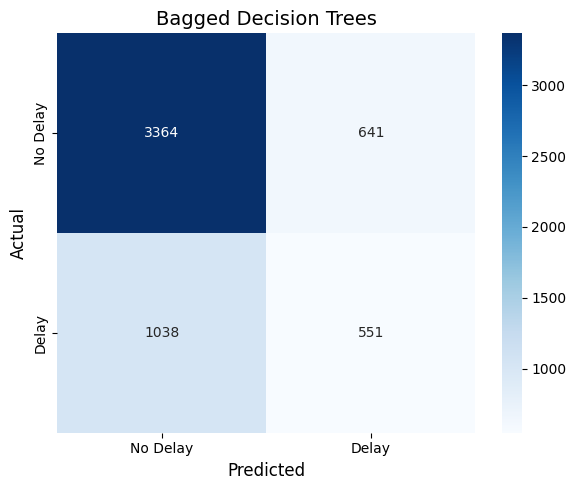

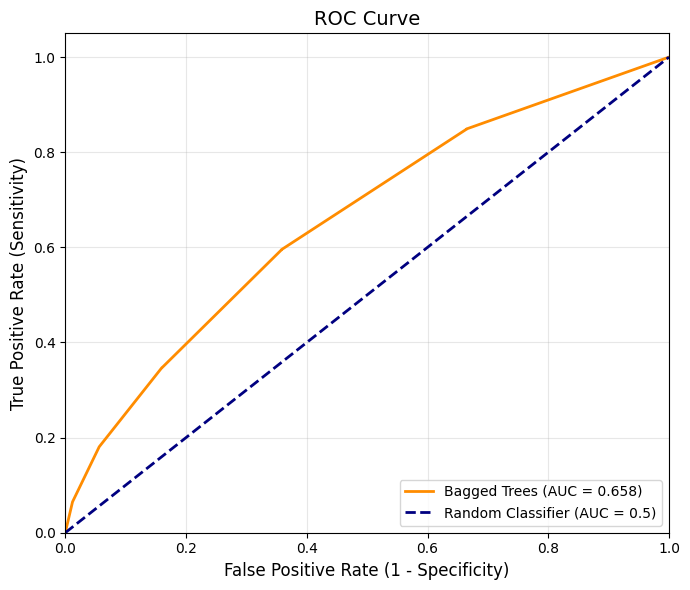

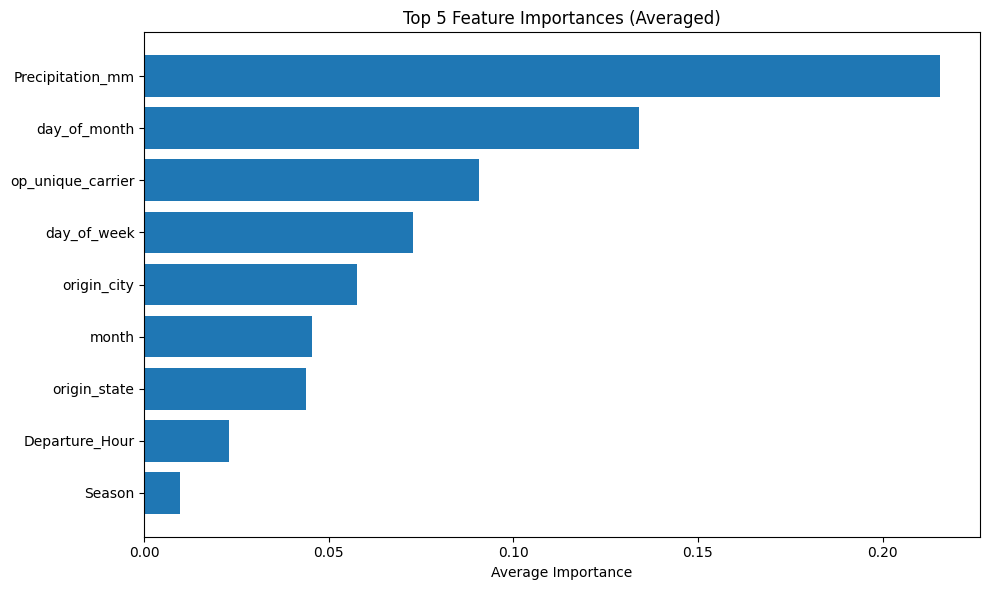

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import numpy as np
# conf matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Delay', 'Delay'],yticklabels=['No Delay', 'Delay'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Bagged Decision Trees', fontsize=14)
plt.tight_layout()
plt.show()



# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'Bagged Trees (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


all_trees = model_bag.estimators_
# Average 
avg_importances = np.mean([tree.feature_importances_ for tree in all_trees], axis=0)
features = X.columns

# Create dataframe for easy viewing
importance_df = pd.DataFrame({'feature': features,'importance': avg_importances}).sort_values('importance', ascending=False)
importance_df = importance_df[importance_df['feature'] != 'dep_time']


# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df.head(10)['feature'], importance_df.head(10)['importance'])
plt.xlabel('Average Importance')
plt.title('Top 5 Feature Importances (Averaged)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# KNN

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Create encoding for hour, month, day of week
def add_cyclical_features(df):
    df_cyclical = df.copy()
    
    df_cyclical['hour_sin'] = np.sin(2 * np.pi * df_cyclical['Departure_Hour'] / 24)
    df_cyclical['hour_cos'] = np.cos(2 * np.pi * df_cyclical['Departure_Hour'] / 24)
    df_cyclical['month_sin'] = np.sin(2 * np.pi * df_cyclical['month'] / 12)
    df_cyclical['month_cos'] = np.cos(2 * np.pi * df_cyclical['month'] / 12)
    df_cyclical['dow_sin'] = np.sin(2 * np.pi * df_cyclical['day_of_week'] / 7)
    df_cyclical['dow_cos'] = np.cos(2 * np.pi * df_cyclical['day_of_week'] / 7)
    
    # Drop original
    df_cyclical = df_cyclical.drop(['Departure_Hour', 'month', 'day_of_week'], axis=1)
    
    return df_cyclical

df_1 = df.copy()


# Select columns (keeping dep_time as is for now)
cols = ["month", "day_of_month", "day_of_week", "op_unique_carrier", 
        "origin_city", "origin_state", "dep_time", "Season", 
        "Departure_Hour", "IS_Delay", "Precipitation_mm"]
df_1 = df_1[cols].dropna()
# use subset maybe for demo?
# for some reason it takes way too long so I'm doing only 100k
df_1 = df_1.sample(1000, random_state=811)
print(len(df.columns))
print(f"The dataset size for KNN is: {len(df_1)}")

df_1 = add_cyclical_features(df_1)

# Convert departure time into minutes
df_1['dep_time_minutes'] = (df_1['dep_time'] // 100) * 60 + (df_1['dep_time'] % 100)
df_1 = df_1.drop('dep_time', axis=1)
# One-hot encode categorical
df_1 = pd.get_dummies(df_1, columns=["op_unique_carrier", "origin_city", "origin_state", "Season"], drop_first=True)

X = df_1.drop("IS_Delay", axis=1)
print(len(df.columns))
y = df_1["IS_Delay"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=811)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN and grid search (same as your original)
knn = KNeighborsClassifier()
param_grid = {"n_neighbors": [5, 10, 15, 20],"weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]}

grid = GridSearchCV(knn, param_grid, cv=5, return_train_score=True)

# data is split inside fit for cross validations, 5 folds
grid.fit(X_train, y_train)

results = pd.DataFrame(grid.cv_results_)
results = results[["param_n_neighbors", "param_weights", "param_metric", "mean_test_score"]]
results = results.sort_values(by="mean_test_score", ascending=False)

print(results)
print("\nBest Parameters:", grid.best_params_)
print(f"Best CV Score: {grid.best_score_:.4f}")

# Optional: Evaluate on test set
y_pred = grid.predict(X_test)
print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

48
The dataset size for KNN is: 1000
48
    param_n_neighbors param_weights param_metric  mean_test_score
6                  20       uniform    euclidean          0.73250
7                  20      distance    euclidean          0.73250
14                 20       uniform    manhattan          0.73250
2                  10       uniform    euclidean          0.73125
13                 15      distance    manhattan          0.72875
3                  10      distance    euclidean          0.72750
5                  15      distance    euclidean          0.72625
4                  15       uniform    euclidean          0.72625
15                 20      distance    manhattan          0.72625
12                 15       uniform    manhattan          0.72500
10                 10       uniform    manhattan          0.72375
11                 10      distance    manhattan          0.72250
8                   5       uniform    manhattan          0.71875
0                   5       uniform 

## Analysis of best KNN

In [22]:
best_knn = KNeighborsClassifier(n_neighbors=20, weights='uniform', metric='manhattan')
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1Score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion matrix:")
print(f"TN: {cm[0,0]:5d}  FP: {cm[0,1]:5d}")
print(f"FN: {cm[1,0]:5d}  TP: {cm[1,1]:5d}")

Accuracy:  0.660
Precision: 1.000
Recall:  0.029
F1Score: 0.056
ROC-AUC: 0.617
              precision    recall  f1-score   support

           0       0.66      1.00      0.79       130
           1       1.00      0.03      0.06        70

    accuracy                           0.66       200
   macro avg       0.83      0.51      0.42       200
weighted avg       0.78      0.66      0.53       200


Confusion matrix:
TN:   130  FP:     0
FN:    68  TP:     2


## Hyperparameter tuning results for KNN

Results: 
        param_n_neighbors param_weights param_metric  mean_test_score

**14                 20       uniform    manhattan         0.712573 - best model**

6                  20       uniform    euclidean         0.709388

10                 10       uniform    manhattan         0.708628

12                 15       uniform    manhattan         0.707416

15                 20      distance    manhattan         0.706505

7                  20      distance    euclidean         0.706201

13                 15      distance    manhattan         0.706051

4                  15       uniform    euclidean         0.704686

2                  10       uniform    euclidean         0.704229

5                  15      distance    euclidean         0.701956

11                 10      distance    manhattan         0.695585

3                  10      distance    euclidean         0.688759

8                   5       uniform    manhattan         0.676929

9                   5      distance    manhattan         0.674350

0                   5       uniform    euclidean         0.673287

1                   5      distance    euclidean         0.671922